In [150]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
import yaml
import matplotlib as mpl

with open("../plotting_config.yaml", "r") as fp:
    config = yaml.safe_load(fp)

mpl.rcParams["svg.hashsalt"] = 42



def is_accessable(x):
    result = 0
    if x > 0:
        result = 1
    return result


def generate_access_variables(data: pd.DataFrame) -> pd.DataFrame:
    copy = data.copy()
    for t in ["_multimodal", "_walk15"]:
        for e in essential:
            copy[e+t+"_d"] = copy[e+t].apply(is_accessable)

    copy["multimodal_sum"] = copy[[f"{i}_multimodal_d" for i in essential]].sum(axis=1)
    copy["walk_sum"] = copy[[f"{i}_walk15_d" for i in essential]].sum(axis=1)

    copy["multimodal_all"] = copy[[f"{i}_multimodal" for i in essential]].sum(axis=1)
    copy["walk_all"] = copy[[f"{i}_walk15" for i in essential]].sum(axis=1)

    return copy

ValueError: Key svg.hashsalt: Could not convert 42 to str

In [9]:
essential = ["cultural_institutions", "drugstores", "groceries", "healthcare", "parks", "religious_organizations", "restaurants", "schools", "services"]

In [3]:
bud = pd.read_csv("../output/budapest/20250428/indicators_with_ses.csv")
hel = pd.read_csv("../output/helsinki/20250428/indicators_with_ses.csv")
mad = pd.read_csv("../output/madrid/20250415/indicators_with_ses.csv")

In [20]:
bud = generate_access_variables(bud)
hel = generate_access_variables(hel)
mad = generate_access_variables(mad)

In [ ]:
labels=["6 or less", "7", "8", "9"],

In [35]:
pd.cut(bud["multimodal_sum"], bins=[-1, 6, 7, 8, 9], labels=["6 or less", "7", "8", "9"], right=True)

0       9
1       9
2       9
3       9
4       9
       ..
1721    9
1722    9
1723    9
1724    9
1725    9
Name: multimodal_sum, Length: 1726, dtype: category
Categories (4, object): ['6 or less' < '7' < '8' < '9']

In [68]:
b = bud[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "multimodal"
h = hel[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "multimodal"
m = mad[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "multimodal"
mm = pd.concat([b, h, m])
mm = mm.rename(columns={"multimodal_all": "access_all", "multimodal_sum": "access_sum"})
b = bud[["stop_id", "walk_all", "walk_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "walk15"
h = hel[["stop_id", "walk_all", "walk_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "walk15"
m = mad[["stop_id", "walk_all", "walk_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "walk15"
w15 = pd.concat([b, h, m])
w15 = w15.rename(columns={"walk_all": "access_all", "walk_sum": "access_sum"})
to_plot = pd.concat([mm, w15])
to_plot["access_all_log"] = np.log10(to_plot["access_all"])

In [69]:
to_plot

,stop_id,access_all,access_sum,city,type,access_all_log
0,007877,130,9,Budapest,multimodal,2.113943
1,007879,126,9,Budapest,multimodal,2.100371
2,007881,477,9,Budapest,multimodal,2.678518
3,007883,401,9,Budapest,multimodal,2.603144
4,007884,4503,9,Budapest,multimodal,3.653502
...,...,...,...,...,...,...
2052,17643,33,6,Madrid,walk15,1.518514
2053,17688,99,8,Madrid,walk15,1.995635
2054,18927,89,8,Madrid,walk15,1.949390
2055,18928,85,8,Madrid,walk15,1.929419


<Axes: xlabel='access_all_log', ylabel='Density'>

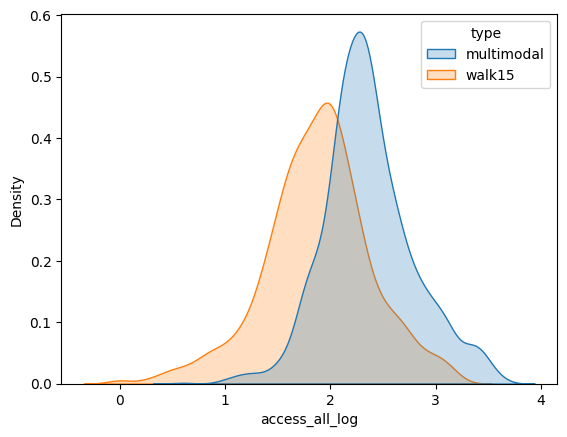

In [75]:
sns.kdeplot(data=to_plot.query("city=='Budapest'"), x="access_all_log", hue="type", fill=True)

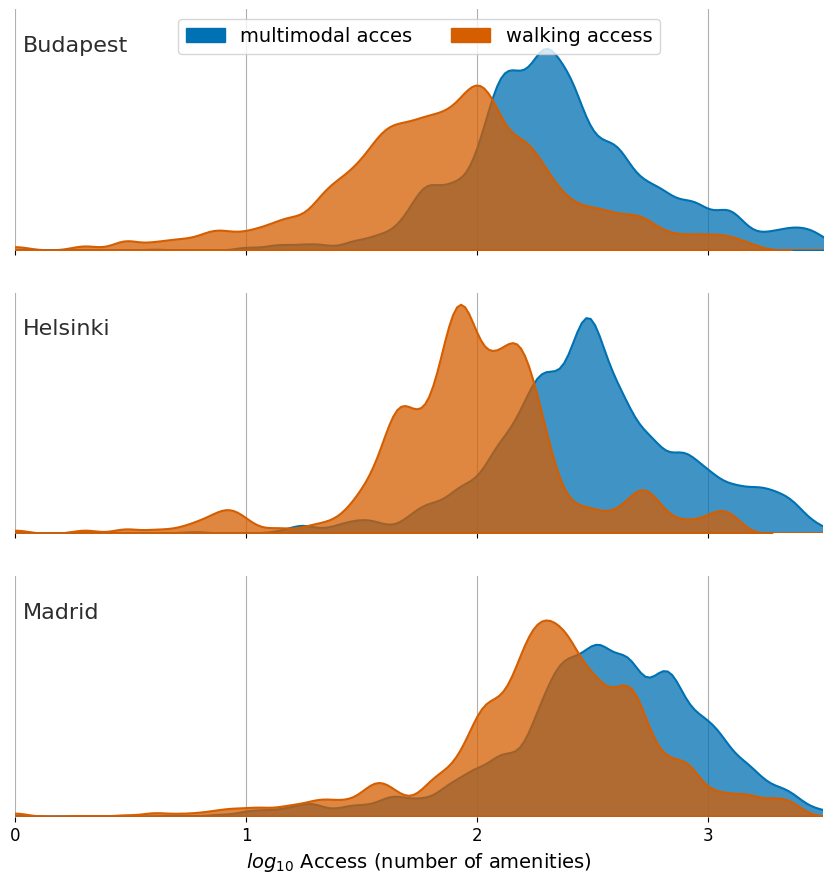

In [155]:
g = sns.FacetGrid(to_plot, row="city", hue="type", aspect=3, height=3, xlim=[0,3.5], palette=["#0071b2", "#d55e00"], legend_out=True)

# Draw the densities in a few steps
g.map(sns.kdeplot, "access_all_log",
      bw_adjust=.5, clip_on=True,
      fill=True, alpha=0.75, linewidth=1.5, legend=True,)
# g.map(sns.kdeplot, "access_all_log", clip_on=True, color="w", lw=2, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=True)


for city, ax in g.axes_dict.items():
    ax.text(0.01, 0.85, city, color="#2d2d2d", fontdict=dict(size=16),
            ha="left", va="center", transform=ax.transAxes)
    ax.set_facecolor("none")

elements = [
    Patch(color="#0071b2", label="multimodal acces"),
    Patch(color="#d55e00", label="walking access")
]
g.axes_dict["Budapest"].legend(handles=elements, ncols=2, loc="upper center", fontsize=14)

# Set the subplots to overlap
# g.figure.subplots_adjust(hspace=-.25)
# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("$log_{10}$ Access (number of amenities)", fontsize=14)
g.despine(bottom=True, left=True)
g.set(xticks=range(0, 4))
g.set_xticklabels(range(0, 4), fontsize=12)
for ax in g.axes.flatten():
    ax.set_axisbelow(True)
    ax.grid()  

for i in ["png", "svg", "pdf"]:
    g.savefig(f"../output/figures/access_distribution_by_city.{i}")